# Supermarket Sales Analysis
### Data Analytics Capstone Project
**Submitted by:** Harsh Agrawal  
**Program:** IBM SkillsBuild Internship  
**Domain:** Retail Data Analytics  
**Dataset:** `SUPER MARKET DATA.xlsx` (500 Sales Transactions)  

---

### Project Overview
The primary objective of this project is to perform an end-to-end data analysis on supermarket transactional logs. By exploring sales performance across products, branches, categories, payment methods, customer profiles, and satisfaction ratings, this project provides actionable, data-driven recommendations to help retail managers optimize inventory, boost revenue, and improve customer experience.

### Analytical Pipeline:
1. **Data Loading & Inspection**: Accessing and examining the 500-transaction dataset.
2. **Data Cleaning & Validation**: Verifying data integrity, checking for nulls/duplicates, and validating sales calculations.
3. **Exploratory Data Analysis (EDA)**: Answering the core business questions formulated in the project guidelines.
4. **Data Visualization**: Constructing clear charts to highlight performance disparities.
5. **Business Decisions & Recommendations**: Formulating practical retail strategies based on the analytical findings.

In [1]:
# Import core data analysis and visualization libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Data Loading & Initial Inspection
We load the supermarket transaction data. The code automatically detects the dataset whether running in a local Python environment or on Google Colab.

In [2]:
# Load dataset (supports both local environment and Google Colab)
file_candidates = ['SUPER MARKET DATA.xlsx', 'SUPER MARKET DATA.csv']
dataset_path = None

for path in file_candidates:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    try:
        from google.colab import files
        print("Please upload 'SUPER MARKET DATA.xlsx' or 'SUPER MARKET DATA.csv':")
        uploaded = files.upload()
        dataset_path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("Dataset file not found in current working directory.")

print(f"Loaded dataset: {dataset_path}")
if dataset_path.endswith('.csv'):
    df = pd.read_csv(dataset_path)
else:
    df = pd.read_excel(dataset_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Loaded dataset: SUPER MARKET DATA.xlsx
Dataset Shape: 500 rows, 13 columns



,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


## 2. Data Cleaning & Integrity Verification
Before performing calculations, we inspect data types, check for null/missing entries, identify any duplicate records, and verify the formula `Sales = Quantity * Unit Price`.

In [3]:
# Check data types and non-null values
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values Count ===")
print(df.isnull().sum())

print(f"\nDuplicate Records: {df.duplicated().sum()}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice ID     500 non-null    object        
 1   Date           500 non-null    datetime64[ns]
 2   Branch         500 non-null    object        
 3   City           500 non-null    object        
 4   Customer Type  500 non-null    object        
 5   Gender         500 non-null    object        
 6   Product        500 non-null    object        
 7   Category       500 non-null    object        
 8   Quantity       500 non-null    int64         
 9   Unit Price     500 non-null    float64       
 10  Payment        500 non-null    object        
 11  Rating         500 non-null    float64       
 12  Sales          500 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 50.9+ KB

=== Missing Values Count =

### Verification: Sales = Quantity × Unit Price
We confirm that the recorded `Sales` figures match the expected product of `Quantity` and `Unit Price`.

In [4]:
# Validate Sales = Quantity * Unit Price
df['Calculated_Sales'] = (df['Quantity'] * df['Unit Price']).round(2)
max_diff = (df['Sales'].round(2) - df['Calculated_Sales']).abs().max()

print(f"Maximum Discrepancy between Sales and Quantity * Unit Price: {max_diff:.4f}")
if max_diff < 0.01:
    print("Verification Successful: All 500 records satisfy Sales = Quantity * Unit Price.")

# Convert Date to datetime and extract time components
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Day_Name'] = df['Date'].dt.strftime('%A')

print(f"\nTransaction Period: {df['Date'].min().strftime('%d %B %Y')} to {df['Date'].max().strftime('%d %B %Y')}")
print(f"Total Revenue Generated: INR {df['Sales'].sum():,.2f}")
print(f"Total Items Sold: {df['Quantity'].sum():,} units")

Maximum Discrepancy between Sales and Quantity * Unit Price: 0.0000
Verification Successful: All 500 records satisfy Sales = Quantity * Unit Price.

Transaction Period: 01 January 2026 to 01 July 2026
Total Revenue Generated: INR 244,411.08
Total Items Sold: 2,768 units


## 3. Exploratory Data Analysis & Answering Core Questions
We now address the core analytical questions defined in the capstone project specification.

### Question 1: Which product generates the highest sales?

In [5]:
# Product sales aggregation
prod_stats = df.groupby('Product').agg(
    Total_Sales=('Sales', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Transactions=('Invoice ID', 'count'),
    Avg_Price=('Unit Price', 'mean')
).sort_values(by='Total_Sales', ascending=False)

top_product = prod_stats.index[0]
print(f"Answer: {top_product} generated the highest sales: INR {prod_stats.loc[top_product, 'Total_Sales']:,.2f}\n")
print("Top 5 Products by Sales Revenue:")
print(prod_stats.head(5))

Answer: Cheese generated the highest sales: INR 27,906.30

Top 5 Products by Sales Revenue:
             Total_Sales  Units_Sold  Transactions   Avg_Price
Product                                                       
Cheese          27906.30         126            26  221.708846
Coffee          27694.87         153            24  181.010833
Shampoo         27497.48         152            27  179.290000
Cooking Oil     21525.06         142            26  150.553846
Tea             17681.59         146            29  119.868966


### Question 2: Which branch performs best?

In [6]:
# Branch and City performance summary
branch_stats = df.groupby(['Branch', 'City']).agg(
    Total_Sales=('Sales', 'sum'),
    Orders=('Invoice ID', 'count'),
    Avg_Order_Value=('Sales', 'mean'),
    Avg_Rating=('Rating', 'mean')
).sort_values(by='Total_Sales', ascending=False)

best_b = branch_stats.index[0]
print(f"Answer: Branch {best_b[0]} ({best_b[1]}) performed best with sales of INR {branch_stats.loc[best_b, 'Total_Sales']:,.2f}\n")
print("Branch Performance Summary:")
print(branch_stats)

Answer: Branch C (Mumbai) performed best with sales of INR 72,469.45

Branch Performance Summary:
                  Total_Sales  Orders  Avg_Order_Value  Avg_Rating
Branch City                                                       
C      Mumbai        72469.45     143       506.779371    4.046154
B      Delhi         64116.26     133       482.077143    3.975188
D      Bengaluru     55468.29     119       466.120084    4.092437
A      Jaipur        52357.08     105       498.638857    3.837143


### Question 3: Which category sells the most?

In [7]:
# Category-level sales aggregation
cat_stats = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Quantity_Sold=('Quantity', 'sum'),
    Transactions=('Invoice ID', 'count')
).sort_values(by='Total_Sales', ascending=False)

top_category = cat_stats.index[0]
print(f"Answer: {top_category} had the highest sales with INR {cat_stats.loc[top_category, 'Total_Sales']:,.2f}\n")
print("Category Sales Breakdown:")
print(cat_stats)

Answer: Beverages had the highest sales with INR 56,108.24

Category Sales Breakdown:
               Total_Sales  Quantity_Sold  Transactions
Category                                               
Beverages         56108.24            465            82
Personal Care     45943.96            399            73
Dairy             43992.00            345            68
Grocery           40470.47            439            82
Fruits            23263.17            223            44
Snacks            16992.97            443            75
Vegetables        11124.17            290            48
Bakery             6516.10            164            28


### Question 4: What is the most popular payment method?

In [8]:
# Payment method aggregation
payment_stats = df.groupby('Payment').agg(
    Transaction_Count=('Invoice ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Avg_Transaction_Value=('Sales', 'mean')
).sort_values(by='Transaction_Count', ascending=False)

top_pay = payment_stats.index[0]
print(f"Answer: {top_pay} was the most used payment method with {payment_stats.loc[top_pay, 'Transaction_Count']} transactions.\n")
print("Payment Methods Summary:")
print(payment_stats)

Answer: UPI was the most used payment method with 127 transactions.

Payment Methods Summary:
             Transaction_Count  Total_Sales  Avg_Transaction_Value
Payment                                                           
UPI                        127     67910.33             534.727008
Net Banking                126     65194.93             517.420079
Card                       125     57265.64             458.125120
Cash                       122     54040.18             442.952295


### Question 5: Do Members spend more than Normal customers?

In [9]:
# Customer Type spending comparison
cust_stats = df.groupby('Customer Type').agg(
    Avg_Spend=('Sales', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Transactions=('Invoice ID', 'count')
)

member_avg = cust_stats.loc['Member', 'Avg_Spend']
normal_avg = cust_stats.loc['Normal', 'Avg_Spend']

print(f"Answer: No. The average Member transaction was INR {member_avg:.2f}, while Normal customers averaged INR {normal_avg:.2f}.")
print(f"However, Members account for INR {cust_stats.loc['Member', 'Total_Sales']:,.2f} (58.5% of total sales) due to higher transaction volume ({cust_stats.loc['Member', 'Transactions']} vs {cust_stats.loc['Normal', 'Transactions']} orders).\n")
print(cust_stats)

Answer: No. The average Member transaction was INR 483.14, while Normal customers averaged INR 497.07.
However, Members account for INR 143,009.30 (58.5% of total sales) due to higher transaction volume (296 vs 204 orders).

                Avg_Spend  Total_Sales  Transactions
Customer Type                                       
Member         483.139527    143009.30           296
Normal         497.067549    101401.78           204


### Question 6: What is the average customer rating?

In [10]:
# Overall and Branch-wise rating calculation
overall_rating = df['Rating'].mean()
print(f"Answer: The average customer rating was {overall_rating:.2f} out of 5.0.\n")

print("Average Rating by Branch:")
print(df.groupby('Branch')['Rating'].mean().round(2))

Answer: The average customer rating was 3.99 out of 5.0.

Average Rating by Branch:
Branch
A    3.84
B    3.98
C    4.05
D    4.09
Name: Rating, dtype: float64


## 4. Data Visualizations
In this section, we present visual charts comparing the analytical results across products, branches, categories, payments, customer types, and monthly trends.

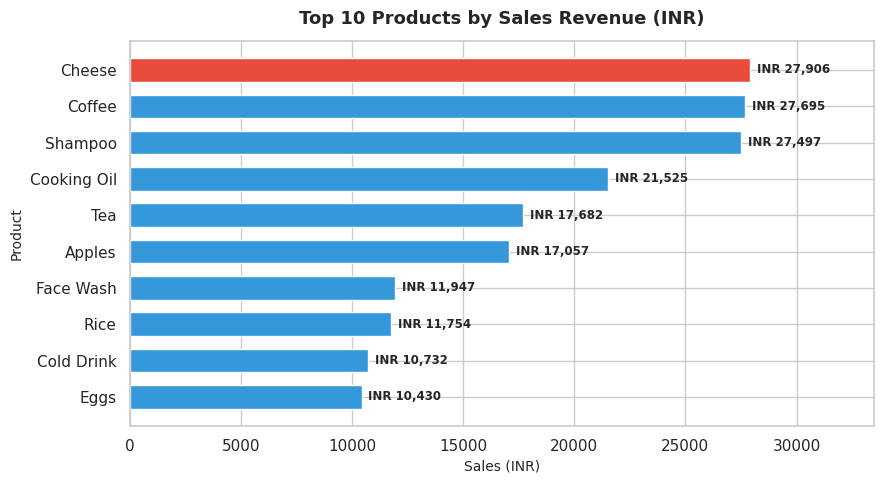

In [11]:
# Visualization 1: Top 10 Products by Sales Revenue
plt.figure(figsize=(9, 5))
top10_p = prod_stats.head(10).sort_values(by='Total_Sales', ascending=True)
colors = ['#3498DB' if p != top_product else '#E74C3C' for p in top10_p.index]
bars = plt.barh(top10_p.index, top10_p['Total_Sales'], color=colors, height=0.65)

plt.title('Top 10 Products by Sales Revenue (INR)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Sales (INR)', fontsize=10)
plt.ylabel('Product', fontsize=10)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 300, bar.get_y() + bar.get_height()/2.0, f"INR {w:,.0f}", va='center', fontsize=8.5, fontweight='bold')

plt.xlim(0, top10_p['Total_Sales'].max() * 1.2)
plt.tight_layout()
plt.show()

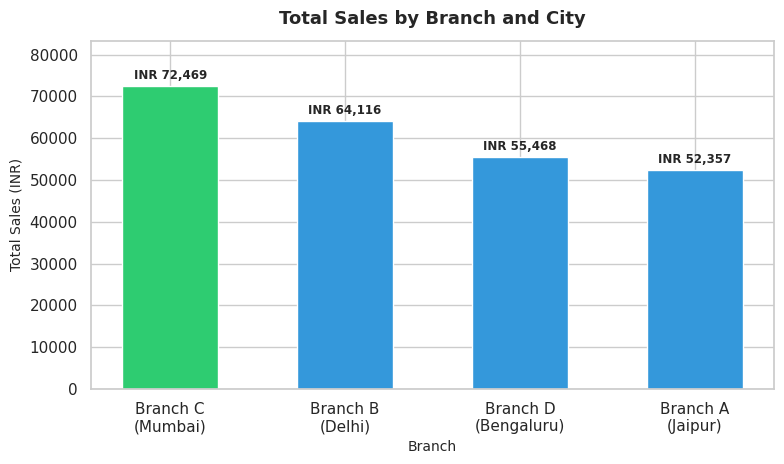

In [12]:
# Visualization 2: Total Sales across Supermarket Branches
plt.figure(figsize=(8, 4.8))
b_labels = [f"Branch {b}\n({c})" for b, c in branch_stats.index]
colors = ['#2ECC71' if b == 'C' else '#3498DB' for b, c in branch_stats.index]

bars = plt.bar(b_labels, branch_stats['Total_Sales'], color=colors, width=0.55)
plt.title('Total Sales by Branch and City', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Total Sales (INR)', fontsize=10)
plt.xlabel('Branch', fontsize=10)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, h + 1000, f"INR {h:,.0f}", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.ylim(0, branch_stats['Total_Sales'].max() * 1.15)
plt.tight_layout()
plt.show()

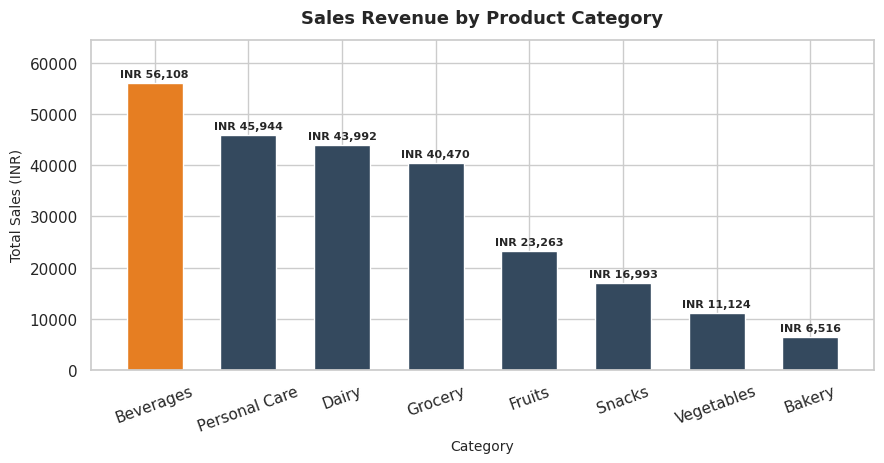

In [13]:
# Visualization 3: Sales by Product Category
plt.figure(figsize=(9, 4.8))
colors = ['#E67E22' if c == top_category else '#34495E' for c in cat_stats.index]

bars = plt.bar(cat_stats.index, cat_stats['Total_Sales'], color=colors, width=0.6)
plt.title('Sales Revenue by Product Category', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Total Sales (INR)', fontsize=10)
plt.xlabel('Category', fontsize=10)
plt.xticks(rotation=20)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, h + 800, f"INR {h:,.0f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.ylim(0, cat_stats['Total_Sales'].max() * 1.15)
plt.tight_layout()
plt.show()

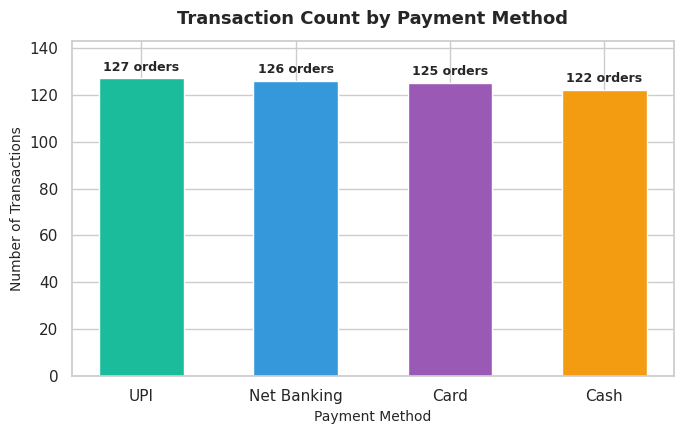

In [14]:
# Visualization 4: Payment Method Distribution
plt.figure(figsize=(7, 4.5))
palette = ['#1ABC9C', '#3498DB', '#9B59B6', '#F39C12']

bars = plt.bar(payment_stats.index, payment_stats['Transaction_Count'], color=palette, width=0.55)
plt.title('Transaction Count by Payment Method', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Number of Transactions', fontsize=10)
plt.xlabel('Payment Method', fontsize=10)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, h + 2, f"{h} orders", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, payment_stats['Transaction_Count'].max() + 16)
plt.tight_layout()
plt.show()

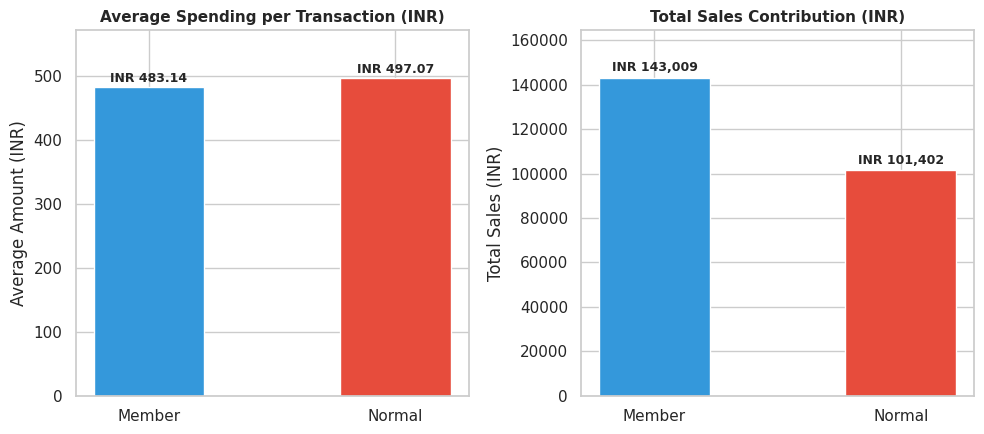

In [15]:
# Visualization 5: Customer Type Comparison (Average Spending vs Total Contribution)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# Subplot 1: Average Spend
ax1.bar(cust_stats.index, cust_stats['Avg_Spend'], color=['#3498DB', '#E74C3C'], width=0.45)
ax1.set_title('Average Spending per Transaction (INR)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Amount (INR)')
for i, (idx, row) in enumerate(cust_stats.iterrows()):
    ax1.text(i, row['Avg_Spend'] + 8, f"INR {row['Avg_Spend']:.2f}", ha='center', fontweight='bold', fontsize=9)
ax1.set_ylim(0, cust_stats['Avg_Spend'].max() * 1.15)

# Subplot 2: Total Sales
ax2.bar(cust_stats.index, cust_stats['Total_Sales'], color=['#3498DB', '#E74C3C'], width=0.45)
ax2.set_title('Total Sales Contribution (INR)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Total Sales (INR)')
for i, (idx, row) in enumerate(cust_stats.iterrows()):
    ax2.text(i, row['Total_Sales'] + 3000, f"INR {row['Total_Sales']:,.0f}", ha='center', fontweight='bold', fontsize=9)
ax2.set_ylim(0, cust_stats['Total_Sales'].max() * 1.15)

plt.tight_layout()
plt.show()

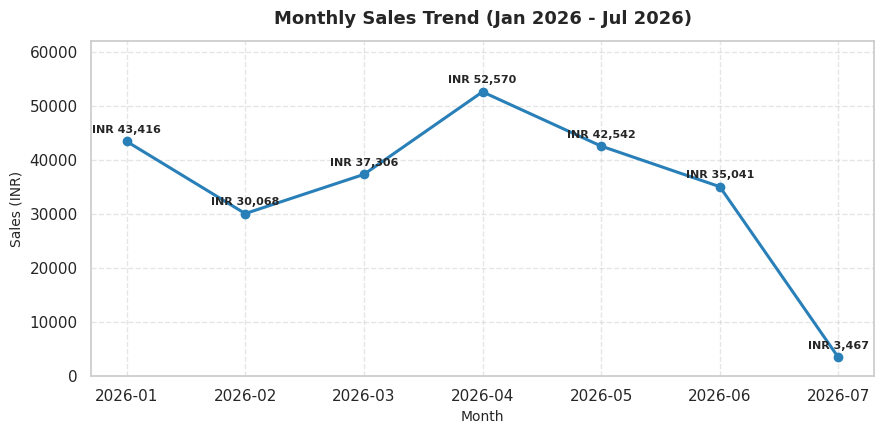

In [16]:
# Visualization 6: Monthly Sales Trend
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(9, 4.5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#2980B9', linewidth=2.2, markersize=6)
plt.title('Monthly Sales Trend (Jan 2026 - Jul 2026)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Sales (INR)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

for i, (m, v) in enumerate(monthly_sales.items()):
    plt.text(i, v + 1200, f"INR {v:,.0f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.ylim(0, monthly_sales.max() * 1.18)
plt.tight_layout()
plt.show()

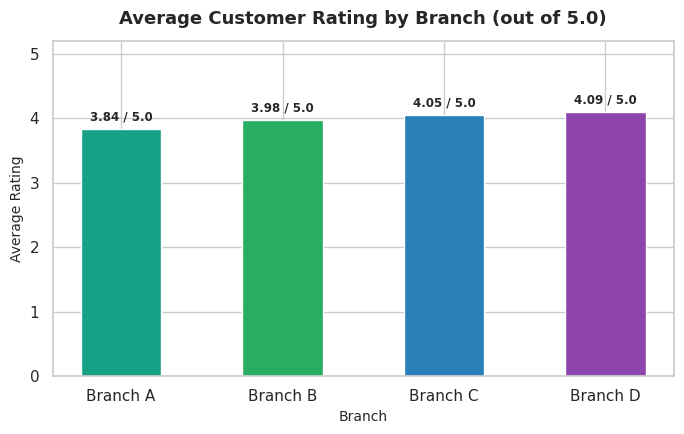

In [17]:
# Visualization 7: Average Rating by Branch
plt.figure(figsize=(7, 4.5))
branch_ratings = df.groupby('Branch')['Rating'].mean()
colors = ['#16A085', '#27AE60', '#2980B9', '#8E44AD']

bars = plt.bar(['Branch ' + b for b in branch_ratings.index], branch_ratings.values, color=colors, width=0.5)
plt.title('Average Customer Rating by Branch (out of 5.0)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Average Rating', fontsize=10)
plt.xlabel('Branch', fontsize=10)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, h + 0.08, f"{h:.2f} / 5.0", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.ylim(0, 5.2)
plt.tight_layout()
plt.show()

## 5. Business Decisions & Actionable Recommendations
Based on the quantitative findings, supermarket leadership can implement the following strategic measures:

1. **Inventory Prioritization**:
   - High-velocity revenue earners such as **Cheese** (₹27,906.30), **Coffee** (₹27,694.87), and **Shampoo** (₹27,497.48) should never stock out. Automated reorder thresholds should be established.
   - **Beverages** and **Personal Care** represent the highest revenue categories and should receive prominent shelf space and end-cap displays.

2. **Branch Operational Benchmarking**:
   - **Branch C (Mumbai)** generated the highest total revenue (₹72,469.45) across 143 transactions. The operational model, staff scheduling, and product placement used in Mumbai should be documented and implemented in lower-volume stores such as **Branch A (Jaipur)**.

3. **Digital Payment Acceleration**:
   - Digital channels (**UPI** and **Net Banking**) together account for over 50% of orders. Supermarkets should expand dedicated express lanes for UPI QR code scanning to reduce checkout wait times during peak hours.

4. **Membership Value Proposition**:
   - Although Normal customers have a slightly higher average spend per order (₹497.07 vs ₹483.14), Members provide **58.5%** of overall revenue due to repeat visits.
   - To raise Member spend per visit, introduce tier-based incentives (e.g., "Spend ₹600 or more to earn double reward points").

5. **Customer Satisfaction Initiatives**:
   - While the supermarket maintains a healthy overall rating of **3.99 / 5.0**, **Branch A** in Jaipur lags at **3.84**. Management should conduct targeted customer surveys focusing on billing speed and staff service at Branch A.

## 6. Conclusion
This project demonstrates how raw retail transaction data can be cleaned, verified, analyzed, and visualized using Python. By translating 500 sales records into actionable business intelligence, retail executives can make informed decisions regarding stock optimization, branch operations, customer retention, and payment processing.

---
**Project Author:** Harsh Agrawal  
**Program:** IBM SkillsBuild Internship  
**Submission Date:** September 2026